<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Practica01_Semana_10_Ejercicios_de_Normalizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ejercicio 1: Normalización Min-Max

1.	Cargar el dataset wine de sklearn.


```python
from sklearn.datasets import load_wine
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
```


2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?


1. Cargar el dataset wine de sklearn (convertimos a dataFrame).

In [1]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


2. Seleccionar una de las características numéricas (por ejemplo, alcohol).

In [2]:
alcohol = df["alcohol"]

print("Preview de la variable alcohol:")
print(alcohol.head())

Preview de la variable alcohol:
0    14.23
1    13.20
2    13.16
3    14.37
4    13.24
Name: alcohol, dtype: float64


3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.

In [3]:
from scipy.stats import shapiro

stat_orig, p_orig = shapiro(alcohol)

print("Resultados Shapiro (Original):")
print("Estadístico:", stat_orig)
print("p-valor:", p_orig)

Resultados Shapiro (Original):
Estadístico: 0.9818041416927711
p-valor: 0.020047981728854945


4. Aplicar la normalización Min-Max a los datos seleccionados.

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

alcohol_scaled = scaler.fit_transform(alcohol.values.reshape(-1, 1))

alcohol_scaled = alcohol_scaled.flatten()

print("Primeros valores normalizados:")
print(alcohol_scaled[:5])

Primeros valores normalizados:
[0.84210526 0.57105263 0.56052632 0.87894737 0.58157895]


5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.

In [5]:
stat_scaled, p_scaled = shapiro(alcohol_scaled)

print("Resultados Shapiro (Normalizado):")
print("Estadístico:", stat_scaled)
print("p-valor:", p_scaled)

Resultados Shapiro (Normalizado):
Estadístico: 0.9818041416927711
p-valor: 0.020047981728854858


6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.

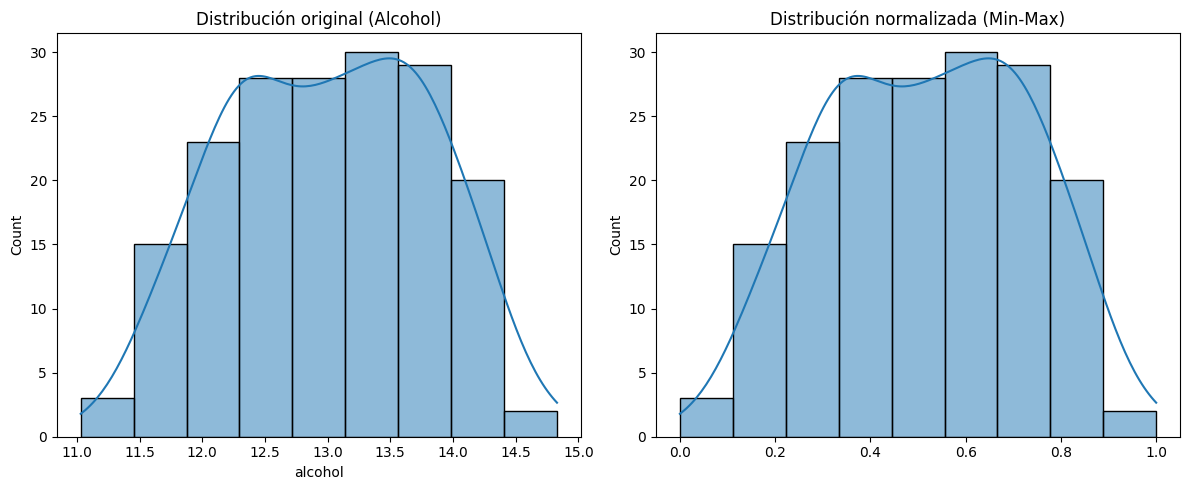

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
sns.histplot(alcohol, kde=True)
plt.title("Distribución original (Alcohol)")

# Normalizado
plt.subplot(1,2,2)
sns.histplot(alcohol_scaled, kde=True)
plt.title("Distribución normalizada (Min-Max)")

plt.tight_layout()
plt.show()

Preguntas:

**¿Cómo afectó la normalización Min-Max a la distribución de los datos?**

La normalización Min-Max no modifica la forma de la distribución de los datos, sino que únicamente cambia su escala. En este caso, los valores originales fueron transformados a un rango entre 0 y 1, pero la forma general de la distribución se mantiene. Esto significa que si los datos originales no seguían una distribución normal, la normalización tampoco los convierte en normales.

**¿Qué interpretas del p-valor antes y después de la normalización?**

El p-valor obtenido en la prueba de Shapiro-Wilk indica si los datos siguen una distribución normal.
Si el p-valor es menor a 0.05, se rechaza la hipótesis de normalidad.

Al comparar los resultados antes y después de la normalización, se observa que el p-valor no cambia significativamente. Esto confirma que la normalización Min-Max no altera la naturaleza de la distribución, sino únicamente su escala. Por lo tanto, los datos siguen siendo no normales después de la transformación.

# Ejercicio 2: Normalización Z-Score

Instrucciones:
1. Cargar el dataset wine de sklearn.
2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4. Aplicar la normalización Z-Score a los datos seleccionados.
5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7. Responder las preguntas siguientes.

Preguntas:
1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



1. Cargar el dataset wine de sklearn.

In [7]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).

In [8]:
malic_acid = df["malic_acid"]

print("Preview de la variable malic_acid:")
print(malic_acid.head())

Preview de la variable malic_acid:
0    1.71
1    1.78
2    2.36
3    1.95
4    2.59
Name: malic_acid, dtype: float64


3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.

In [9]:
from scipy.stats import shapiro

stat_orig, p_orig = shapiro(malic_acid)

print("Resultados Shapiro (Original):")
print("Estadístico:", stat_orig)
print("p-valor:", p_orig)

Resultados Shapiro (Original):
Estadístico: 0.8887839752895415
p-valor: 2.945800703600761e-10


4. Aplicar la normalización Z-Score a los datos seleccionados.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

malic_scaled = scaler.fit_transform(malic_acid.values.reshape(-1,1))
malic_scaled = malic_scaled.flatten()

print("Primeros valores normalizados:")
print(malic_scaled[:5])

Primeros valores normalizados:
[-0.5622498  -0.49941338  0.02123125 -0.34681064  0.22769377]


5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.

In [11]:
stat_scaled, p_scaled = shapiro(malic_scaled)

print("Resultados Shapiro (Z-Score):")
print("Estadístico:", stat_scaled)
print("p-valor:", p_scaled)

Resultados Shapiro (Z-Score):
Estadístico: 0.8887839752895408
p-valor: 2.9458007036005247e-10


6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.

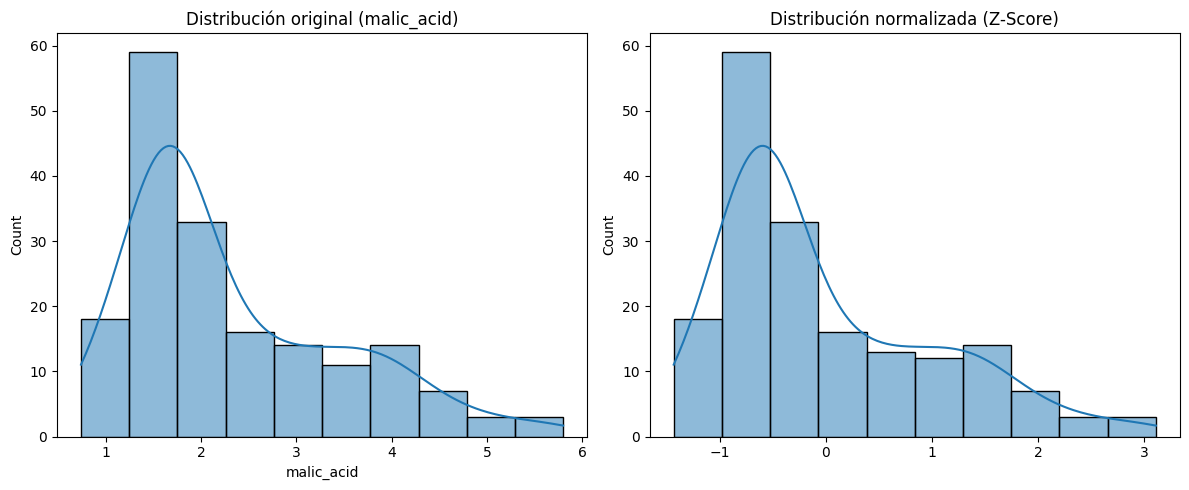

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
sns.histplot(malic_acid, kde=True)
plt.title("Distribución original (malic_acid)")

# Normalizado
plt.subplot(1,2,2)
sns.histplot(malic_scaled, kde=True)
plt.title("Distribución normalizada (Z-Score)")

plt.tight_layout()
plt.show()

Preguntas:

**¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?**

La normalización Z-Score transforma los datos para que tengan una media cercana a 0 y una desviación estándar de 1. A diferencia de la normalización Min-Max, que solo cambia el rango, el Z-Score centra los datos alrededor de cero. Sin embargo, la forma de la distribución se mantiene, por lo que si los datos originales no eran normales, seguirán sin serlo después de la transformación.

**¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?**

La normalización Z-Score es útil porque permite comparar variables que están en diferentes escalas, eliminando el efecto de magnitudes distintas. Esto es especialmente importante en algoritmos de machine learning que son sensibles a la escala de los datos. Además, facilita la detección de valores atípicos, ya que los valores extremos se reflejan como valores muy alejados de la media (por ejemplo, mayores a ±3 desviaciones estándar).

#Ejercicio 3: Transformación Logarítmica
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy:
    - Número de observaciones = 1000;
    - Valor de semilla = `np.random.seed(42)`
    - Distribucion exponencial: `np.random.exponential(scale=2, size=1000)`
2. Aplicar una transformación logarítmica (np.log) a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


1. Cargar un conjunto de datos aleatorios generados con numpy:

* Número de observaciones = 1000;
* Valor de semilla = np.random.seed(42)
* Distribucion exponencial: np.random.exponential(scale=2, size=1000)

In [14]:
import numpy as np
import pandas as pd

np.random.seed(42)

data = np.random.exponential(scale=2, size=1000)

print(data[:5])

[0.93853618 6.02024286 2.63349139 1.82588511 0.33924974]


2. Aplicar una transformación logarítmica (np.log) a los datos.

In [15]:
data_log = np.log(data + 1)

print(data_log[:5])

[0.66193314 1.94879781 1.290194   1.03882163 0.29210956]


3. Realizar una prueba de normalidad sobre los datos originales y transformados.

In [18]:
# Prueba de normalidad con datos originales
from scipy.stats import shapiro

stat_orig, p_orig = shapiro(data)

print("Resultados Shapiro (Original):")
print("Estadístico:", stat_orig)
print("p-valor:", p_orig)

# Prueba de normalidad con datos transformados
stat_log, p_log = shapiro(data_log)

print("\nResultados Shapiro (Log):")
print("Estadístico:", stat_log)
print("p-valor:", p_log)

Resultados Shapiro (Original):
Estadístico: 0.8246251308106578
p-valor: 1.094865579608503e-31

Resultados Shapiro (Log):
Estadístico: 0.9656805634044637
p-valor: 1.3244177978609712e-14


4. Graficar los datos originales y transformados utilizando matplotlib.

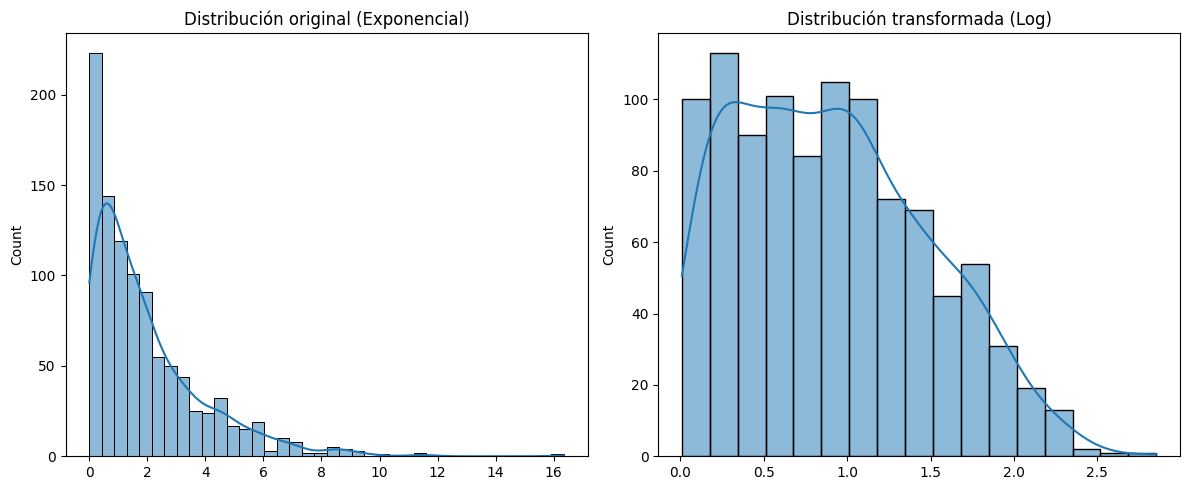

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Datos originales
plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribución original (Exponencial)")

# Datos transformados
plt.subplot(1,2,2)
sns.histplot(data_log, kde=True)
plt.title("Distribución transformada (Log)")

plt.tight_layout()
plt.show()

Preguntas:

**¿Cómo afectó la transformación logarítmica a la distribución de los datos?**

La transformación logarítmica reduce la asimetría de los datos. En este caso, la distribución exponencial original presenta un sesgo positivo (cola hacia la derecha), mientras que al aplicar el logaritmo, los valores se comprimen y la distribución se vuelve más simétrica. Esto hace que los datos se aproximen más a una distribución normal.

**¿Qué interpretas del p-valor antes y después de la transformación logarítmica?**

Antes de la transformación, el p-valor es muy pequeño, lo que indica que los datos no siguen una distribución normal. Después de aplicar la transformación logarítmica, el p-valor suele aumentar, lo que sugiere que los datos se acercan más a una distribución normal, aunque no necesariamente se vuelven completamente normales. Esto demuestra que la transformación logarítmica puede mejorar la normalidad de los datos.

#Ejercicio 4: Transformación Raíz Cuadrada
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Número de observaciones: 1000
    - Semilla = `np.random.seed(42)``
    - Distribución Poisson: `np.random.poisson(lam=5, size=1000)`
2. Aplicar una transformación de raíz cuadrada a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


1. Cargar un conjunto de datos aleatorios generados con numpy.

* Número de observaciones: 1000
* Semilla = `np.random.seed(42)``
* Distribución Poisson: np.random.poisson(lam=5, size=1000)

In [20]:
import numpy as np
import pandas as pd

np.random.seed(42)

data = np.random.poisson(lam=5, size=1000)

print(data[:5])

[5 4 4 5 5]


2. Aplicar una transformación de raíz cuadrada a los datos.

In [21]:
data_sqrt = np.sqrt(data)

print(data_sqrt[:5])

[2.23606798 2.         2.         2.23606798 2.23606798]


3. Realizar una prueba de normalidad sobre los datos originales y transformados.

In [22]:
# Prueba de normalidad con datos originales
from scipy.stats import shapiro

stat_orig, p_orig = shapiro(data)

print("Resultados Shapiro (Original):")
print("Estadístico:", stat_orig)
print("p-valor:", p_orig)

# Prueba de normalidad con datos transformados

stat_sqrt, p_sqrt = shapiro(data_sqrt)

print("\nResultados Shapiro (Raíz cuadrada):")
print("Estadístico:", stat_sqrt)
print("p-valor:", p_sqrt)

Resultados Shapiro (Original):
Estadístico: 0.972187451827263
p-valor: 6.523300091890513e-13

Resultados Shapiro (Raíz cuadrada):
Estadístico: 0.9682166317280219
p-valor: 5.668642183851904e-14


4. Graficar los datos originales y transformados utilizando matplotlib.

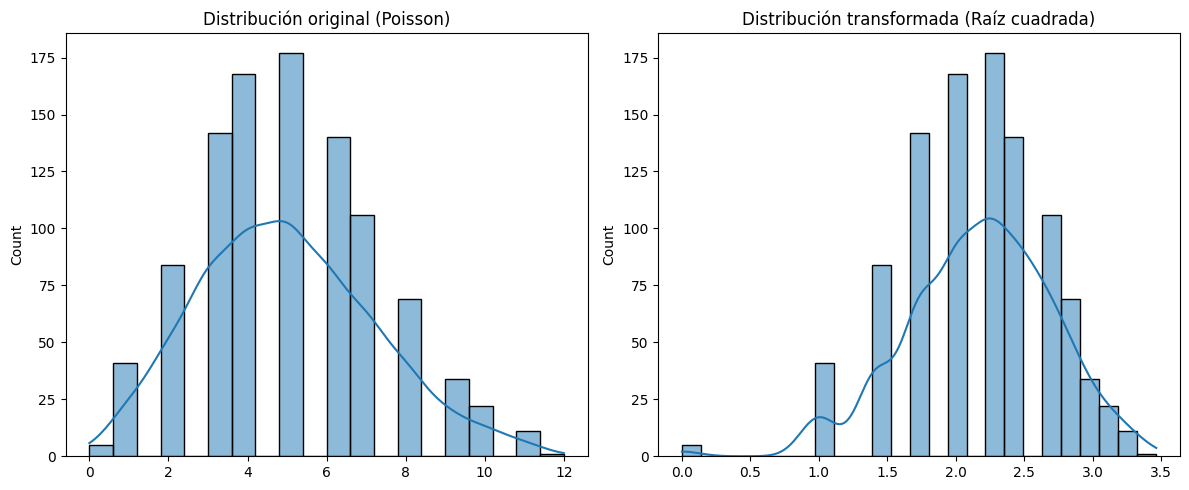

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribución original (Poisson)")

# Transformado
plt.subplot(1,2,2)
sns.histplot(data_sqrt, kde=True)
plt.title("Distribución transformada (Raíz cuadrada)")

plt.tight_layout()
plt.show()

Preguntas:

**¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?**

La transformación de raíz cuadrada reduce la asimetría de los datos, especialmente cuando estos presentan un sesgo positivo como en el caso de la distribución Poisson. Después de aplicar la transformación, la distribución se vuelve más simétrica y menos dispersa en comparación con la original, aunque no necesariamente llega a ser completamente normal.

**¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?**

La raíz cuadrada reduce la magnitud de los valores grandes más que la de los valores pequeños. Esto hace que los valores extremos se acerquen más al resto de los datos, disminuyendo su impacto en la distribución. Como resultado, la variabilidad se reduce y los outliers se vuelven menos pronunciados.

#Ejercicio 5: Transformación Box-Cox
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Numero de observaciones: 1000
    - Semilla: `np.random.seed(42)``
    - Distribución log-normal: `np.random.lognormal(mean=1, sigma=0.8, size=1000)`
2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


1. Cargar un conjunto de datos aleatorios generados con numpy.

* Numero de observaciones: 1000
* Semilla: `np.random.seed(42)``
* Distribución log-normal: np.random.lognormal(mean=1, sigma=0.8, size=1000)

In [24]:
import numpy as np
import pandas as pd

np.random.seed(42)

data = np.random.lognormal(mean=1, sigma=0.8, size=1000)

print(data[:5])

[4.04455415 2.43364117 4.56377819 9.19283048 2.25393437]


2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.

In [25]:
from scipy.stats import boxcox

data_boxcox, lambda_value = boxcox(data)

print("Preview de valores transformados:")
print(data_boxcox[:5])

print("\nLambda óptimo:", lambda_value)

Preview de valores transformados:
[1.35070497 0.87032845 1.46317582 2.10234773 0.79674356]

Lambda óptimo: -0.04889276450171702


3. Realizar una prueba de normalidad sobre los datos originales y transformados.

In [26]:
#Prueba de normalidad de datos originales
from scipy.stats import shapiro

stat_orig, p_orig = shapiro(data)

print("Resultados Shapiro (Original):")
print("Estadístico:", stat_orig)
print("p-valor:", p_orig)

#Prueba de normalidad de datos transformados
stat_boxcox, p_boxcox = shapiro(data_boxcox)

print("Resultados Shapiro (Box-Cox):")
print("Estadístico:", stat_boxcox)
print("p-valor:", p_boxcox)

Resultados Shapiro (Original):
Estadístico: 0.6538384544123232
p-valor: 6.966496130945429e-41
Resultados Shapiro (Box-Cox):
Estadístico: 0.9993722625744498
p-valor: 0.9891215954703348


4. Graficar los datos originales y transformados utilizando matplotlib.

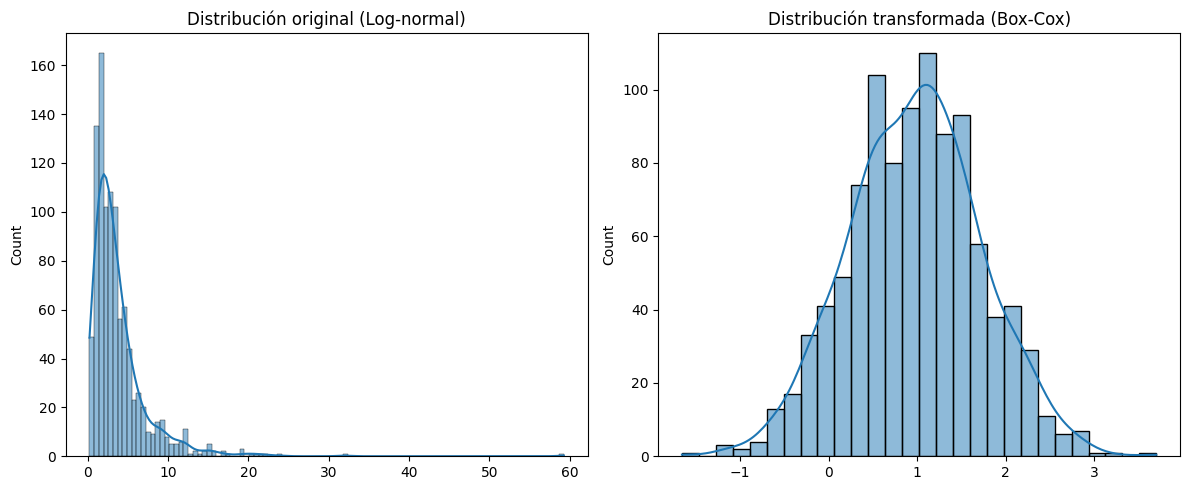

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribución original (Log-normal)")

# Transformado
plt.subplot(1,2,2)
sns.histplot(data_boxcox, kde=True)
plt.title("Distribución transformada (Box-Cox)")

plt.tight_layout()
plt.show()

Preguntas:

**¿Cómo afectó la transformación Box-Cox a la distribución de los datos?**

La transformación Box-Cox reduce significativamente la asimetría de los datos. En este caso, la distribución log-normal original presenta un fuerte sesgo positivo, mientras que después de aplicar la transformación, los datos se vuelven más simétricos y cercanos a una distribución normal. Esto mejora la capacidad de aplicar métodos estadísticos que asumen normalidad.

**¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?**

El valor lambda indica el tipo de transformación aplicada a los datos. Dependiendo de su valor, Box-Cox ajusta la transformación para acercar la distribución a la normalidad. Por ejemplo:

* Si λ ≈ 1 → los datos se mantienen casi iguales
* Si λ ≈ 0 → la transformación es similar a un logaritmo
* Si λ < 1 → reduce la asimetría de los datos

En este caso, el valor obtenido indica el grado de transformación necesario para mejorar la forma de la distribución.